In [1]:
#SIC contour 15% PCA basic - March 2024
import pandas as pd
import xarray as xr
import numpy as np
import glob
import datetime
import numpy as np
from sklearn.decomposition import PCA
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import seaborn as sns  # Optional for aesthetics

data_path  = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0/'
fig_path   = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_fig15/'
shape_path = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15/'

/Users/epauthen/opt/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/Users/epauthen/opt/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


In [2]:
ds = xr.open_mfdataset('/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15_resample.nc')
# Drop NaN values along the 'time' dimension
ds = ds.dropna(dim='time')
ds['day_of_year'] = ds['time'].dt.dayofyear
ds['year'] = ds['time'].dt.year
ds = ds.set_coords('day_of_year')
ds = ds.set_coords('year')
ds

<xarray.Dataset>
Dimensions:      (time: 13677, dist: 1000)
Coordinates:
  * time         (time) datetime64[ns] 1978-10-25T12:00:00 ... 2024-03-06T12:...
  * dist         (dist) int64 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
    day_of_year  (time) int64 298 299 300 301 302 303 304 ... 61 62 63 64 65 66
    year         (time) int64 1978 1978 1978 1978 1978 ... 2024 2024 2024 2024
Data variables:
    C15x         (time, dist) float64 dask.array<chunksize=(13677, 1000), meta=np.ndarray>
    C15y         (time, dist) float64 dask.array<chunksize=(13677, 1000), meta=np.ndarray>

In [10]:
# Assuming you have vectors x and y
x = np.array(ds.C15x.load())  # Example x vector
y = np.array(ds.C15y.load())  # Example y vector

# Stack vectors horizontally
data = np.hstack((x, y))

# Instantiate PCA model
npc = 10
pca = PCA(n_components=npc)  # Specify the number of principal components you want

# Fit PCA model
pca.fit(data)

# Transform data
transformed_data = pca.transform(data)

# Print the percentage of variance explained by each PC
print("Percentage of variance explained by each PC:")
for i, variance_ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance_ratio:.2%}")

    print("Original data shape:", data.shape)
print("Transformed data shape:", transformed_data.shape)
print(f"variance explained of first three modes: {pca.explained_variance_ratio_[:3].sum():.2%}")


Percentage of variance explained by each PC:
PC1: 61.65%
Original data shape: (13677, 2000)
PC2: 25.57%
Original data shape: (13677, 2000)
PC3: 4.23%
Original data shape: (13677, 2000)
PC4: 1.99%
Original data shape: (13677, 2000)
PC5: 1.14%
Original data shape: (13677, 2000)
PC6: 0.82%
Original data shape: (13677, 2000)
PC7: 0.51%
Original data shape: (13677, 2000)
PC8: 0.48%
Original data shape: (13677, 2000)
PC9: 0.38%
Original data shape: (13677, 2000)
PC10: 0.34%
Original data shape: (13677, 2000)
Transformed data shape: (13677, 10)
variance explained of first three modes: 91.45%


In [11]:
ds['PC'] = xr.DataArray(transformed_data, 
                                    dims=('time', 'pca_components'), 
                                    coords={'time': ds.time, 'pca_components': np.arange(1,npc+1)})

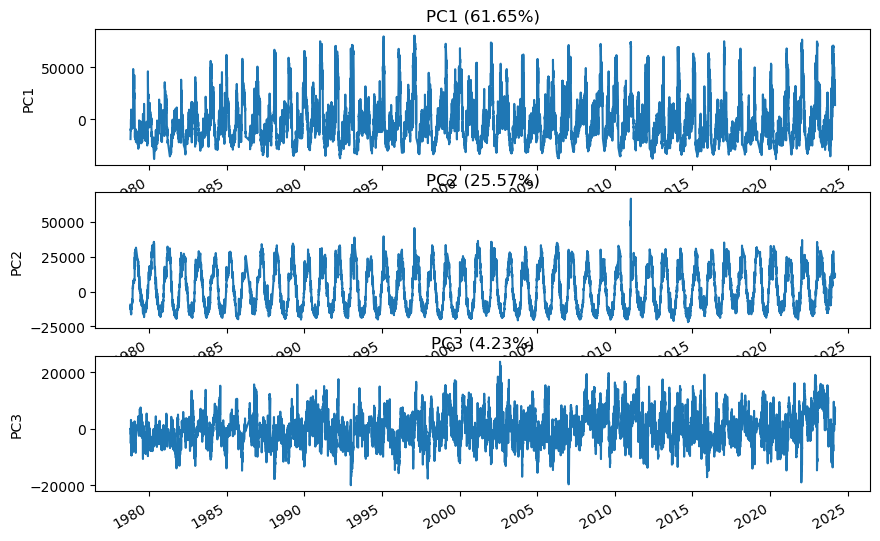

In [12]:
fig,axs = plt.subplots(3,1,figsize = (10,6))
for i, variance_ratio in enumerate(pca.explained_variance_ratio_[0:3]):
    ds.PC.isel(pca_components = i).plot(ax = axs[i])
    axs[i].set_title(f'PC{i+1} ({variance_ratio:.2%})')
    axs[i].set_xlabel('')
    axs[i].set_ylabel(f'PC{i+1}')


In [13]:
#Messed up dates :
dd = ['2024-01-22T12:00:00.000000000', 
      '1979-12-25T12:00:00.000000000', 
      '1979-05-16T12:00:00.000000000', 
      '2002-08-10T12:00:00.000000000']

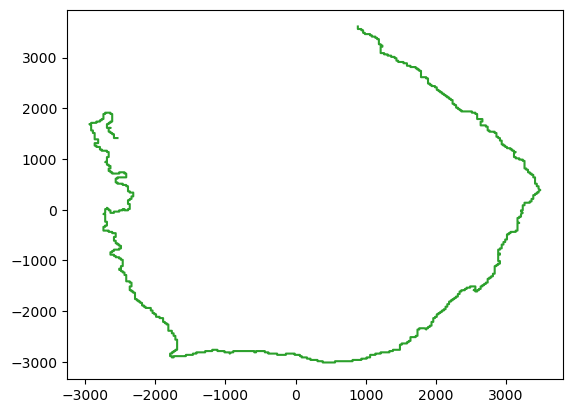

In [14]:
#Drop anomaly
dss = ds.isel(time = ds.PC.isel(pca_components = 2).argmax().data)
plt.plot(dss.C15x,dss.C15y,c = 'tab:green',label = "resampled")
   

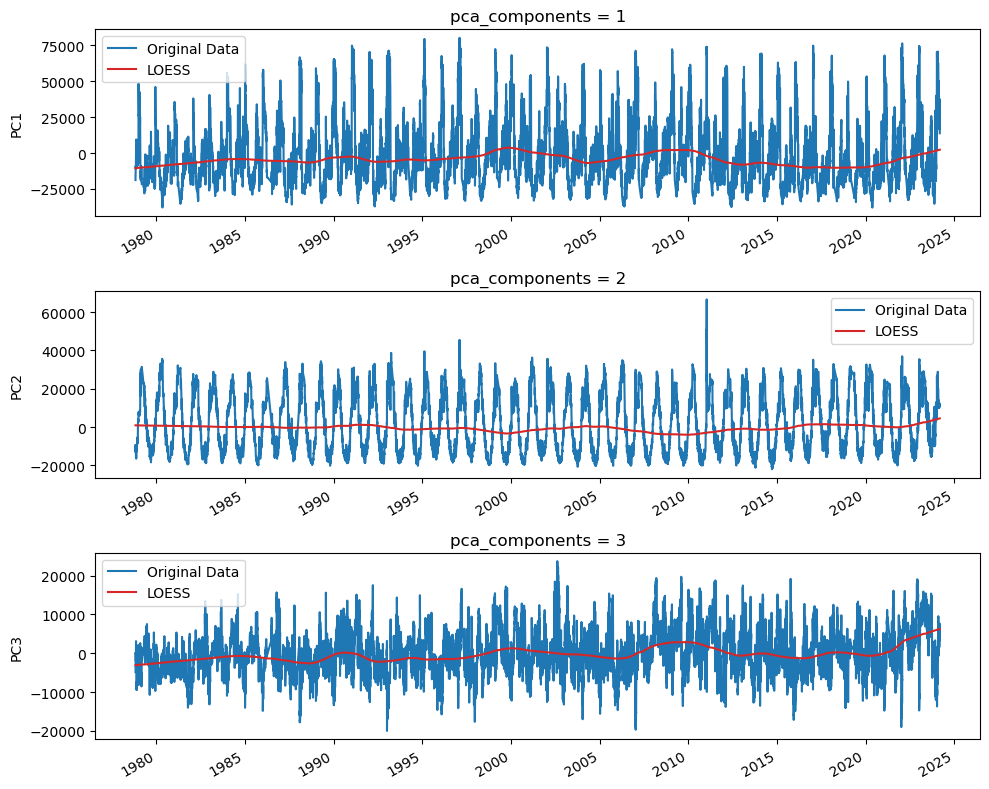

In [94]:
#Add loess
# Assuming ds is an xarray dataset containing time series data

# Create subplots
npc = 3
fig, axs = plt.subplots(npc, 1, figsize=(10, 8))
for i in range(npc):
    # Plot original data
    ds['PC'].isel(pca_components = i).plot(ax=axs[i], label='Original Data', color='tab:blue')
    
    # Fit a LOESS curve
    lowess = sm.nonparametric.lowess(ds['PC'].isel(pca_components = i), np.arange(len(ds.time)), frac=0.1)
    
    # Plot LOESS curve
    axs[i].plot(ds.time, lowess[:, 1], label='LOESS', color='tab:red')
    
    # Set labels and title
    axs[i].set_xlabel('')
    axs[i].set_ylabel(f'PC{i+1}')
    axs[i].legend()

plt.tight_layout()
plt.show()


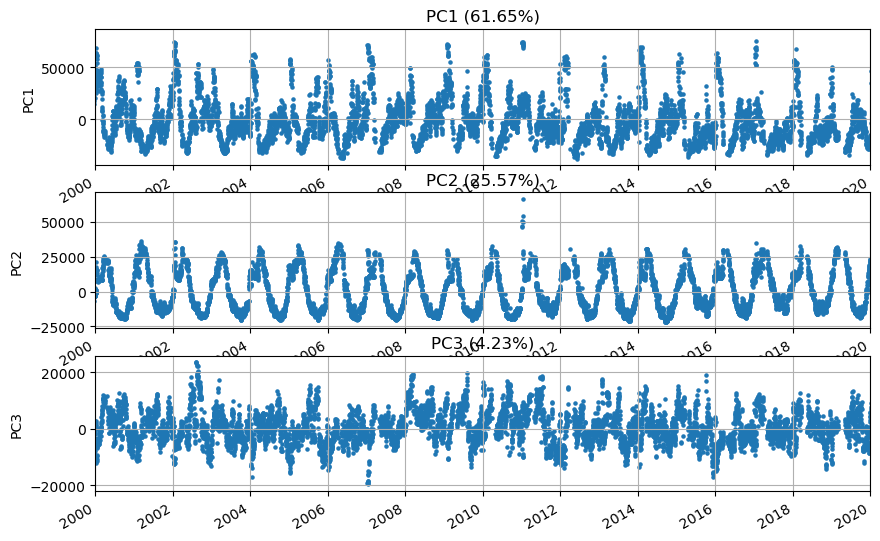

In [161]:
#Zoom
fig,axs = plt.subplots(3,1,figsize = (10,6))
for i, variance_ratio in enumerate(pca.explained_variance_ratio_[0:3]):
    ds.PC.isel(pca_components = i).plot.scatter(ax = axs[i],s = 5, edgecolors='tab:blue')
    axs[i].set_title(f'PC{i+1} ({variance_ratio:.2%})')
    axs[i].set_xlabel('')
    axs[i].set_ylabel(f'PC{i+1}')
    axs[i].set_xlim(pd.Timestamp('2000-01-01'), pd.Timestamp('2020-01-01'))
    axs[i].grid()

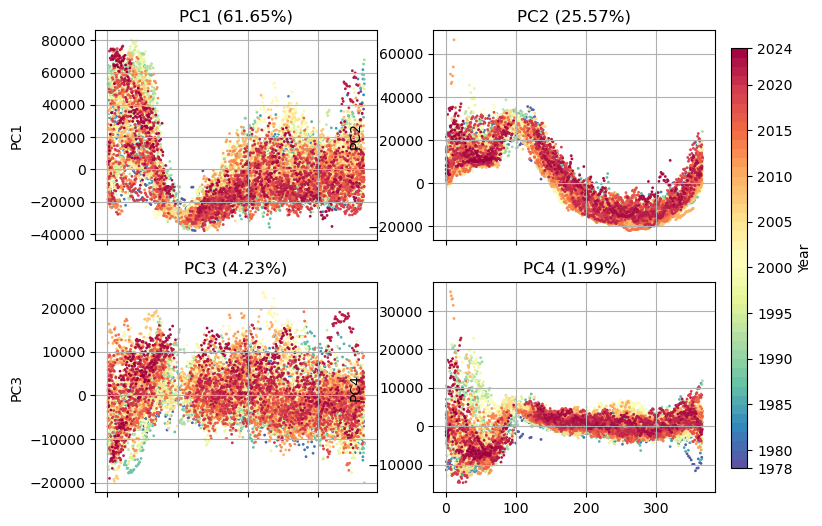

In [137]:
npc = 4
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Define colorbar axis

for i, variance_ratio in enumerate(pca.explained_variance_ratio_[0:npc]):
    ax = axs.flatten()[i]
    sc = ax.scatter(ds['day_of_year'], ds['PC'].isel(pca_components=i), c=ds['year'], cmap='Spectral_r', s=1)
    ax.set_title(f'PC{i+1} ({variance_ratio:.2%})')
    ax.set_xlabel('')
    ax.set_ylabel(f'PC{i+1}')
    ax.grid()

    # Remove xtick labels except for the last subplot
    if i < npc-1:
        ax.set_xticklabels([])

# Create colorbar
ticks = [1978, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]  # Example tick locations
cbar = fig.colorbar(sc, cax=cbar_ax, ticks=ticks, boundaries=range(1978, 2025, 1), spacing='proportional')
#cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Year')
plt.show()

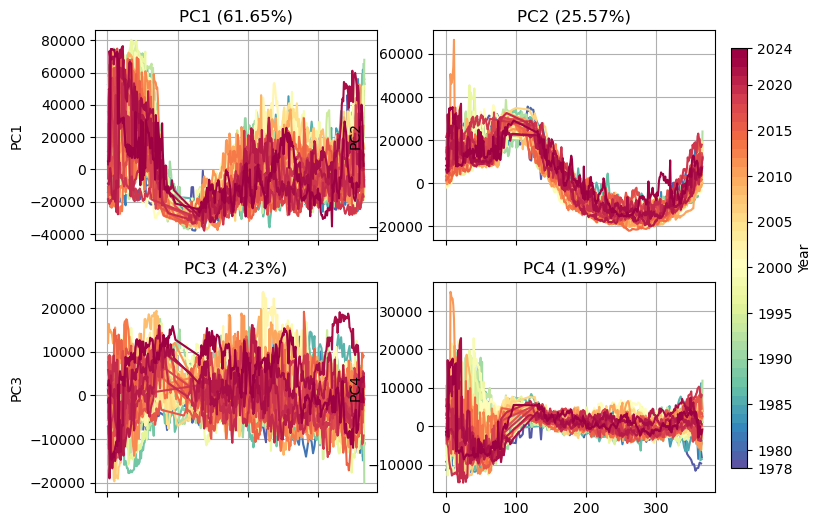

In [150]:
npc = 4
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

norm = Normalize(vmin=1978, vmax=2023)  # Normalize the years for color mapping
cmap = cm.Spectral_r  # Choose the colormap

for i, variance_ratio in enumerate(pca.explained_variance_ratio_[0:npc]):
    ax = axs.flatten()[i]
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    for yy in np.arange(1978, 2024):
        dsy = ds.sel(time=ds['year'] == yy)
        color = sm.to_rgba(yy)
        ax.plot(dsy['day_of_year'], dsy['PC'].isel(pca_components=i), color=color)
    ax.set_title(f'PC{i+1} ({variance_ratio:.2%})')
    ax.set_xlabel('')
    ax.set_ylabel(f'PC{i+1}')
    ax.grid()

    # Remove xtick labels except for the last subplot
    if i < npc-1:
        ax.set_xticklabels([])

# Create colorbar
ticks = [1978, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]  # Example tick locations
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, ticks=ticks, boundaries=range(1978, 2025, 1), spacing='proportional')
cbar.set_label('Year')

plt.show()
